### Group No. - 9<br>
* Rathlavath Vishal - 24EE10081<br>
* Rishabh Sethia - 24EE10082<br>
* Rohit Kumar - 24EE10083<br>

In [16]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets , transforms
import matplotlib.pyplot as plt 

In [17]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,) , (0.5,))
])

train_dataset = datasets.FashionMNIST(
    'F_MNIST_data' , download=True,train=True,transform=transform
)
test_dataset = datasets.FashionMNIST(
    'F_MNIST_data' , download=True,train=False,transform=transform
)

indices = list(range(len(train_dataset)))
np.random.shuffle(indices)
split = int(0.2 * len(train_dataset))
val_ids , train_ids = indices[:split] , indices[split:]
train_sampler = torch.utils.data.SubsetRandomSampler(train_ids)
val_sampler = torch.utils.data.SubsetRandomSampler(val_ids)

BATCH_SIZE = 128
train_loader = torch.utils.data.DataLoader(
    train_dataset,batch_size=BATCH_SIZE,sampler=train_sampler
)

val_loader = torch.utils.data.DataLoader(
    train_dataset,batch_size=BATCH_SIZE,sampler=train_sampler
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,batch_size=BATCH_SIZE,shuffle=False
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Length of train data is 48000
Length of test data is 10000
Length of validation data is 12000
torch.Size([1, 28, 28]) torch.Size([128])
Coat


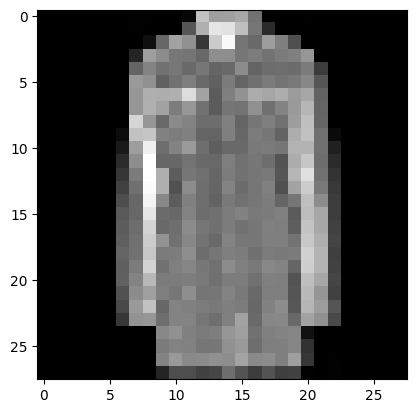

In [21]:
print("Length of train data is " + str(len(train_sampler)))
print("Length of test data is " + str(len(test_dataset)))
print("Length of validation data is " + str(len(val_sampler)))

image, label = next(iter(train_loader))
print(image[0].shape, label.shape) # (1, 28, 28)

desc = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',

'Sandal', 'Shirt','Sneaker', 'Bag', 'Ankle Boot']
print(desc[label[0].item()])
plt.imshow(image[0].numpy().squeeze(), cmap='gray')